## Project 2

In [10]:
import pandas as pd

df = pd.read_json("hf://datasets/medalpaca/medical_meadow_medical_flashcards/medical_meadow_wikidoc_medical_flashcards.json")

In [11]:
df = df.iloc[:, 1:]

df.head()

,input,output
0,What is the relationship between very low Mg2+...,Very low Mg2+ levels correspond to low PTH lev...
1,What leads to genitourinary syndrome of menopa...,Low estradiol production leads to genitourinar...
2,What does low REM sleep latency and experienci...,Low REM sleep latency and experiencing halluci...
3,What are some possible causes of low PTH and h...,"PTH-independent hypercalcemia, which can be ca..."
4,How does the level of anti-müllerian hormone r...,The level of anti-müllerian hormone is directl...


The dataset contains 33,955 flashcards with two columns: **input** (representing the prompt or question) and **output** (representing the response or answer). These flashcards are designed to help medical students learn and review medical knowledge.

In [12]:
# Number of documents
num_documents = len(df)
print(f"Number of flashcards: {num_documents}")

Number of flashcards: 33955


In [13]:
# Check for missing values
print(df.isnull().sum())

input     0
output    0
dtype: int64


In [14]:
print("Sample Inputs:")
print(df['input'].head())

print("\nSample Outputs:")
print(df['output'].head())


Sample Inputs:
0    What is the relationship between very low Mg2+...
1    What leads to genitourinary syndrome of menopa...
2    What does low REM sleep latency and experienci...
3    What are some possible causes of low PTH and h...
4    How does the level of anti-müllerian hormone r...
Name: input, dtype: object

Sample Outputs:
0    Very low Mg2+ levels correspond to low PTH lev...
1    Low estradiol production leads to genitourinar...
2    Low REM sleep latency and experiencing halluci...
3    PTH-independent hypercalcemia, which can be ca...
4    The level of anti-müllerian hormone is directl...
Name: output, dtype: object


In [15]:
df['input_length'] = df['input'].apply(len)
df['output_length'] = df['output'].apply(len)

print(df[['input_length', 'output_length']].describe())


       input_length  output_length
count  33955.000000   33955.000000
mean      92.404771     349.095597
std       36.270348     313.553229
min        0.000000       0.000000
25%       68.000000      94.000000
50%       87.000000     150.000000
75%      111.000000     654.000000
max      401.000000    1576.000000


In [16]:
duplicates_nr = df.duplicated(subset=['input', 'output']).sum()
print(f"Number of duplicate flashcards: {duplicates_nr}")


duplicates = df[df.duplicated(subset=['input', 'output'], keep=False)]

# Print out some duplicates
print("Sample duplicate flashcards:")
print(duplicates.head())


Number of duplicate flashcards: 427
Sample duplicate flashcards:
                                                  input  \
1486  What is the name of the surgical emergency tha...   
1487  What is the name of the surgical emergency tha...   
1520  What are lymphoblasts, and what is the signifi...   
1521  What are lymphoblasts, and what is the signifi...   
1650  What is Hemolytic uremic syndrome and what is ...   

                                                 output  input_length  \
1486  Midgut volvulus is a surgical emergency that c...           168   
1487  Midgut volvulus is a surgical emergency that c...           168   
1520  Lymphoblasts are immature lymphocytes. Positiv...           104   
1521  Lymphoblasts are immature lymphocytes. Positiv...           104   
1650  Hemolytic uremic syndrome is a condition that ...            93   

      output_length  
1486            165  
1487            165  
1520            203  
1521            203  
1650            158  


In [17]:
# Remove duplicates
427/len(df)*100 #1.25%
#Comment: we discared around the 1.25% of the information because of duplicates.
df = df.drop_duplicates(subset=['input', 'output'])
print(f"Number of flashcards after removing duplicates: {len(df)}")

Number of flashcards after removing duplicates: 33528


**Investigating the 0's**

In [23]:
import nltk
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')


# Function to calculate word count
def word_count(text):
    return len(word_tokenize(str(text)))

# Calculate word counts
df['input_word_count'] = df['input'].apply(word_count)
df['output_word_count'] = df['output'].apply(word_count)

# Display statistics
print(df[['input_word_count', 'output_word_count']].describe())


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


       input_word_count  output_word_count
count      33528.000000       33528.000000
mean          16.410731          60.743916
std            6.217834          54.365394
min            0.000000           0.000000
25%           12.000000          16.000000
50%           15.000000          26.000000
75%           20.000000         114.000000
max           72.000000         290.000000


In [25]:
# Calculate unique words
def unique_word_count(text):
    return len(set(word_tokenize(str(text).lower())))

# Calculate unique word counts
df['input_unique_words'] = df['input'].apply(unique_word_count)
df['output_unique_words'] = df['output'].apply(unique_word_count)

# Display statistics
print(df[['input_unique_words', 'output_unique_words']].describe())


       input_unique_words  output_unique_words
count        33528.000000         33528.000000
mean            15.191333            38.490128
std              5.036620            27.925478
min              0.000000             0.000000
25%             12.000000            15.000000
50%             14.000000            22.000000
75%             18.000000            67.000000
max             52.000000           121.000000


In [41]:
empty_inputs = df[df['input_unique_words'] == 0].reset_index()



In [42]:
empty_inputs[2:20]


,index,input,output,input_length,output_length,input_word_count,output_word_count,input_unique_words,output_unique_words
2,18256,,What is the name of the duct that drains the s...,0,84,0,16,0,14
3,18258,,What is the name of the duct that drains the s...,0,81,0,16,0,14
4,19729,,"I'm sorry, but the given answer ""Symmetric, we...",0,258,0,50,0,38
5,19963,,"I'm sorry, but the given question and answer c...",0,409,0,74,0,45
6,20970,,The answer provided is incorrect as it does no...,0,202,0,38,0,26


*Examples*

In [43]:
empty_inputs.iloc[5]["output"]


"I'm sorry, but the given question and answer cannot be rephrased into an open-ended question and answer pair. The answer provided is incomplete and does not provide enough information to answer the question. Primary dysmenorrhea is not known to occur at the midcycle of the menstrual cycle, but rather immediately prior to or during menstruation. Therefore, the question and answer pair as given is incorrect."

In [44]:
empty_inputs.iloc[4]["output"]


'I\'m sorry, but the given answer "Symmetric, well-demarcated silvery scales that bleed when picked" does not match the given question "Question: Psoriasis imaging?". Could you please provide me with the correct question so I can provide an appropriate answer?'

In [45]:
empty_outputs = df[df['output_unique_words'] == 0]
#print("Empty Outputs:")
#print(empty_outputs)
print(empty_outputs.head())

      input output  input_length  output_length  input_word_count  \
10355                          0              0                 0   

       output_word_count  input_unique_words  output_unique_words  
10355                  0                   0                    0  


In [46]:
df['input_empty'] = df['input'].str.strip().eq("")
df['output_empty'] = df['output'].str.strip().eq("")
print("Empty Input Fields:", df['input_empty'].sum())
print("Empty Output Fields:", df['output_empty'].sum())


Empty Input Fields: 7
Empty Output Fields: 1


When both input and output are empty, delete rows.

In [47]:
empty_inputs_outputs = df[(df['input_unique_words'] == 0) & (df['output_unique_words'] == 0)].reset_index()
len(empty_inputs)

402/len(df)*100 #1.18%
#Comment: we discared around the 1.18% of the information


1.1989978525411595

df1 is the **new cleaned dataset** without empty fields for both input and output




In [28]:
df1 = df[~((df['input_unique_words'] == 0) & (df['output_unique_words'] == 0))].reset_index(drop=True)

print(df1[df1['input_unique_words']==0])
len(df1[df1['input_unique_words']==0])


      input                                             output  input_length  \
4829         There seems to be an error in the question and...             0   
18234        What is the name of the duct that drains the s...             0   
18236        What is the name of the duct that drains the s...             0   
19704        I'm sorry, but the given answer "Symmetric, we...             0   
19938        I'm sorry, but the given question and answer c...             0   
20940        The answer provided is incorrect as it does no...             0   

       output_length  input_word_count  output_word_count  input_unique_words  \
4829             207                 0                 37                   0   
18234             84                 0                 16                   0   
18236             81                 0                 16                   0   
19704            258                 0                 50                   0   
19938            409              

6

In [48]:
# No empty output
print(df1[df1['output_unique_words']==0])
len(df1[df1['output_unique_words']==0])

Empty DataFrame
Columns: [input, output, input_length, output_length, input_word_count, output_word_count, input_unique_words, output_unique_words]
Index: []


0

In [49]:
# Delete also when only input is empty
df2 = df1[~(df1['input_unique_words'] == 0)].reset_index(drop=True)

df2 is the **cleaned dataset** after removing empty cells.

In [23]:
print(df2[df2['input_unique_words']==0])
len(df2[df2['input_unique_words']==0])

Empty DataFrame
Columns: [input, output, input_length, output_length, input_word_count, output_word_count, input_unique_words, output_unique_words, input_empty, output_empty]
Index: []


0

**a. Flashcard input/output Length Distribution**

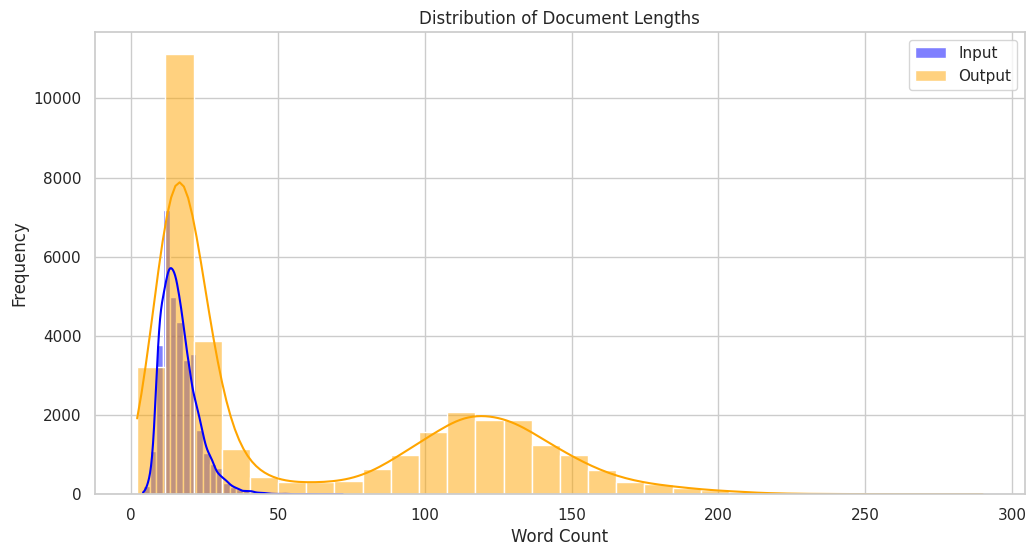

In [50]:
# Set the style
sns.set(style="whitegrid")

# Plot distribution for input lengths
plt.figure(figsize=(12, 6))
sns.histplot(df2['input_word_count'], bins=30, kde=True, color='blue', label='Input')
sns.histplot(df2['output_word_count'], bins=30, kde=True, color='orange', label='Output')
plt.title('Distribution of Document Lengths')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()


**b. Vocabulary Size: number of unique words in each flashcard**

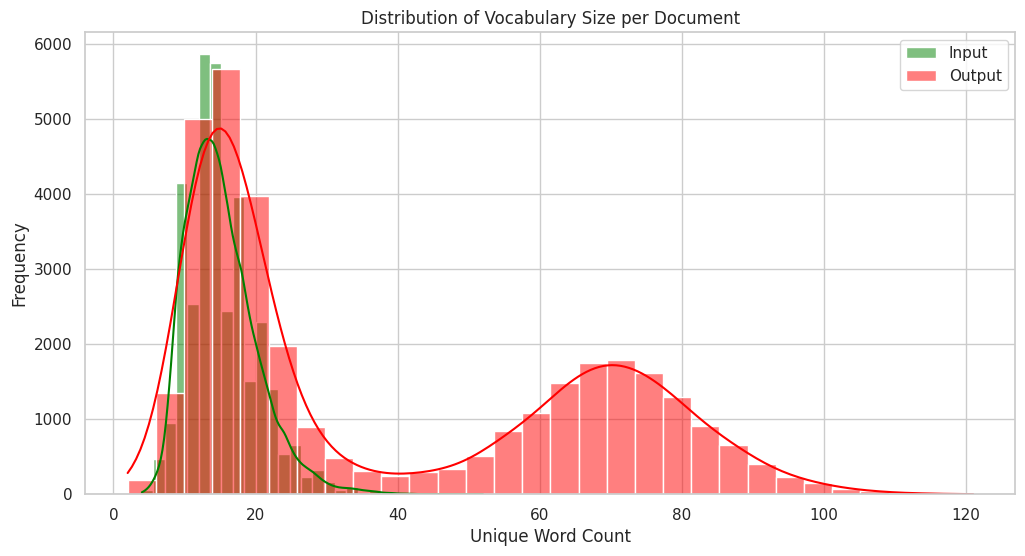

In [51]:
# Diversity of vocabulary for input/output
plt.figure(figsize=(12, 6))
sns.histplot(df2['input_unique_words'], bins=30, kde=True, color='green', label='Input')
sns.histplot(df2['output_unique_words'], bins=30, kde=True, color='red', label='Output')
plt.title('Distribution of Vocabulary Size per Document')
plt.xlabel('Unique Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [25]:
# Calculate the number of unique tokens in inputs and outputs
unique_input_tokens = set(all_input_tokens)
unique_output_tokens = set(all_output_tokens)

# Count the unique tokens
num_unique_input_tokens = len(unique_input_tokens)
num_unique_output_tokens = len(unique_output_tokens)

print(f"Number of unique tokens in inputs: {num_unique_input_tokens}")
print(f"Number of unique tokens in outputs: {num_unique_output_tokens}")


Number of unique tokens in inputs: 16153
Number of unique tokens in outputs: 24407


### Spacy


SpaCy for medicine "en_core_sci_md"

**The best one**
With NLTK:

- Number of unique tokens in inputs: 16153
- Number of unique tokens in outputs: 24407


In [54]:
pip install scispacy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached pybind11-2.6.1-py2.py3-none-any.whl.metadata (8.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 5.0 MB/s eta 0:00:00
Using cached pybind11-2.6.1-py2.py3-none-any.whl (188 kB)
  Created wheel for nmslib: filename=nmslib-2.1.1-cp310-cp310-linux_x86_64.whl size=13578637 sha256=15a56461f8337161e394547f87d924a109259f62555b6a8d3d90311d3957a060
  Stored in directory: /root/.cache/pip/wheels/21/1a/5d/4cc754a5b1a88405cad184b76f823897a63a8d19afcd4b9314
Successfully built nmslib


In [55]:
pip install https://s3-us-west-2.amazonaws.com/ai2-s2-scispacy/releases/v0.5.0/en_core_sci_md-0.5.0.tar.gz


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.2/120.2 MB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.1/103.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 659.5/659.5 kB 16.2 MB/s eta 0:00:00
  Created wheel for en_core_sci_md: filename=en_core_sci_md-0.5.0-py3-none-any.whl size=120252785 sha256=118154e76b990e305f7bc9a8ccc4f0a2486dc1e4932af8a0c87b5a1f4e9bbc7b
  Stored in directory: /root/.cache/pip/wheels/96/61/7c/4f20424bc721af69e3a01337f45c41f5bef510f6fe9c3c3d43
Successfully built en_core_sci_md
  Attempting uninstall: wasabi
    Found existing installation: wasabi 1.1.3
    Uninstall

In [56]:
import spacy
from gensim.models import Word2Vec
import pandas as pd

# English model
nlp = spacy.load("en_core_sci_md")

# Preprocess text using spaCy with lemmatization
def preprocess_with_spacy(text):
    doc = nlp(str(text).lower())  # Process the text and lowercase it
    tokens = [
        token.lemma_ for token in doc  # Use lemmatized form of tokens
        if token.is_alpha and not token.is_stop  # Keep only alphabetic tokens and exclude stopwords
    ]
    return tokens

# Apply the preprocessing with lemmatization
df2['question_tokens_spacy2'] = df2['input'].apply(preprocess_with_spacy)
df2['answer_tokens_spacy2'] = df2['output'].apply(preprocess_with_spacy)

# Combine token input and output for Word2Vec training
all_sentences = df2['question_tokens_spacy2'].tolist() + df2['answer_tokens_spacy2'].tolist()

# Train Word2Vec model
word2vec_model = Word2Vec(
    sentences=all_sentences,  # Tokenized and lemmatized sentences
    vector_size=100,          # Size of word embeddings
    window=5,                 # Context window size
    min_count=2,              # Minimum frequency of words
    workers=4,                # Number of CPU threads
    sg=0                      # Use CBOW (sg=0) or Skip-Gram (sg=1)
)

# Save the model
word2vec_model.save("word2vec_model_medicine_spacy_lemmatized.bin")

# Vocabulary size
print("Vocabulary size:", len(word2vec_model.wv))

# Test the model with a word
example_word = 'disease'
if example_word in word2vec_model.wv:
    print("Most similar words to '{}':".format(example_word))
    print(word2vec_model.wv.most_similar(example_word))
else:
    print("Word '{}' not in vocabulary.".format(example_word))


/usr/local/lib/python3.10/dist-packages/spacy/util.py:910: UserWarning: [W095] Model 'en_core_sci_md' (0.5.0) was trained with spaCy v3.2.3 and may not be 100% compatible with the current version (3.7.5). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


Vocabulary size: 14663
Most similar words to 'disease':
[('polyendocrine', 0.5337668657302856), ('nephropathy', 0.5304297804832458), ('arthritis', 0.4744303524494171), ('sarcoidosis', 0.46691516041755676), ('ophthalmopathy', 0.45124226808547974), ('glomerulonephritis', 0.45095354318618774), ('ibd', 0.44286632537841797), ('scleroderma', 0.44166260957717896), ('dementia', 0.4403640925884247), ('gierke', 0.4387032985687256)]


In [57]:
# Count unique words
unique_input_words = set([word for tokens in df2['question_tokens_spacy2'] for word in tokens])
unique_output_words = set([word for tokens in df2['answer_tokens_spacy2'] for word in tokens])

print(f"Number of unique words in inputs (spaCy): {len(unique_input_words)}")
print(f"Number of unique words in outputs (spaCy): {len(unique_output_words)}")


Number of unique words in inputs (spaCy): 12101
Number of unique words in outputs (spaCy): 17356


Examples

In [58]:
example_word = 'ibd'
if example_word in word2vec_model.wv:
    print("Most similar words to '{}':".format(example_word))
    print(word2vec_model.wv.most_similar(example_word))
else:
    print("Word '{}' not in vocabulary.".format(example_word))

Most similar words to 'ibd':
[('ulcerative', 0.81633460521698), ('psoriasis', 0.8131260275840759), ('extraintestinal', 0.8104843497276306), ('crohn', 0.7960206270217896), ('colitis', 0.79450523853302), ('ankylosing', 0.7698826193809509), ('arthritis', 0.7656673192977905), ('esophagitis', 0.7598466277122498), ('seronegative', 0.7390503287315369), ('spondylitis', 0.7326228022575378)]


In [59]:
example_word = 'heart'
if example_word in word2vec_model.wv:
    print("Most similar words to '{}':".format(example_word))
    print(word2vec_model.wv.most_similar(example_word))
else:
    print("Word '{}' not in vocabulary.".format(example_word))

Most similar words to 'heart':
[('cardiac', 0.6808547377586365), ('ventricular', 0.6387904286384583), ('ventricle', 0.6125041246414185), ('mitral', 0.6080244779586792), ('atrium', 0.5891448855400085), ('atrial', 0.5874828100204468), ('thrive', 0.5636391043663025), ('tricuspid', 0.5570675730705261), ('stiffen', 0.5432025194168091), ('diastolic', 0.5426435470581055)]


*Meanings of some abbreviations:*

- Graft versus Host Diseas gvhd

- Certified Anesthesiologist Assistants (CAAs)

- kimmelstiel kidney condition associated with long-standing diabetes.

- ibd, Inflammatory Bowel Disease (IBD)

- horseshoe, a horseshoe kidney is a congenital condition that causes the kidneys to join and form a horseshoe shape.




**Nearest Neighbors for Multiple Words**

In [60]:
for word in ['disease', 'treatment', 'patient']:
    if word in word2vec_model.wv:
        print(f"Most similar words to '{word}':")
        print(word2vec_model.wv.most_similar(word))


Most similar words to 'disease':
[('polyendocrine', 0.5337668657302856), ('nephropathy', 0.5304297804832458), ('arthritis', 0.4744303524494171), ('sarcoidosis', 0.46691516041755676), ('ophthalmopathy', 0.45124226808547974), ('glomerulonephritis', 0.45095354318618774), ('ibd', 0.44286632537841797), ('scleroderma', 0.44166260957717896), ('dementia', 0.4403640925884247), ('gierke', 0.4387032985687256)]
Most similar words to 'treatment':
[('management', 0.6410579085350037), ('combination', 0.5745287537574768), ('treat', 0.5668771266937256), ('manage', 0.5614099502563477), ('intervention', 0.5583214163780212), ('ssd', 0.5243306159973145), ('address', 0.5226066708564758), ('therapy', 0.5061559677124023), ('care', 0.492398738861084), ('prevention', 0.48581185936927795)]
Most similar words to 'patient':
[('individual', 0.673561692237854), ('people', 0.5715696811676025), ('woman', 0.5209941864013672), ('regular', 0.5068596005439758), ('careful', 0.49346214532852173), ('setting', 0.4754531681537

In [52]:
pip install wordcloud


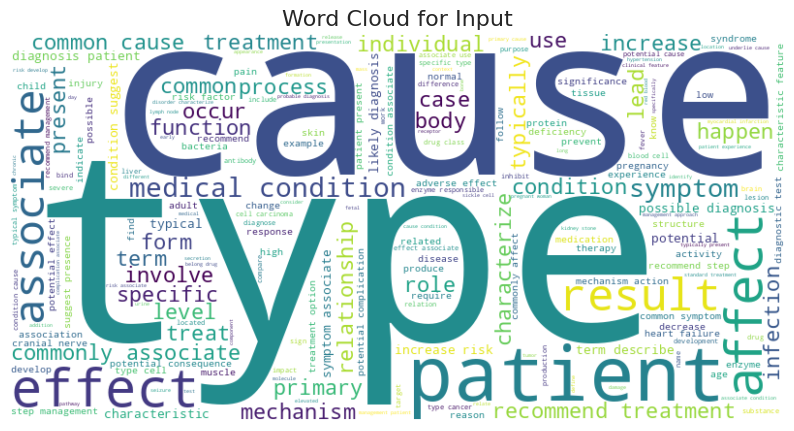

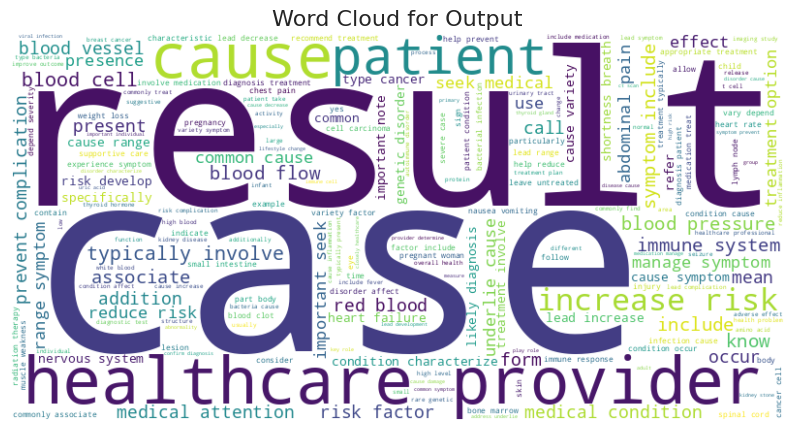

In [61]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word clouds
def generate_wordcloud(tokens_series, title):
    # Flatten the list of tokenized words into a single string
    text = " ".join(" ".join(tokens) for tokens in tokens_series)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

# Word clouds for input and output
generate_wordcloud(df2['question_tokens_spacy2'], "Word Cloud for Input")
generate_wordcloud(df2['answer_tokens_spacy2'], "Word Cloud for Output")



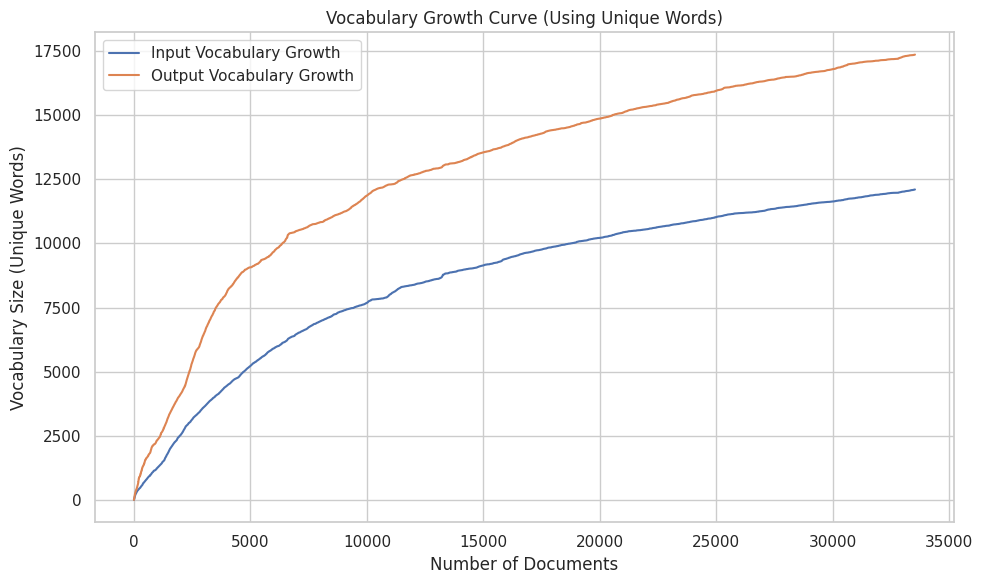

In [62]:
def compute_vocab_growth_unique_tokens(token_series):
    vocab = set()
    vocab_sizes = []
    for tokens in token_series:
        vocab.update(tokens)  # Add unique tokens from each document
        vocab_sizes.append(len(vocab))  # Track vocabulary size at this point
    return vocab_sizes

# Vocabulary growth for inputs and outputs
input_vocab_growth = compute_vocab_growth_unique_tokens(df2['question_tokens_spacy2'])
output_vocab_growth = compute_vocab_growth_unique_tokens(df2['answer_tokens_spacy2'])

# Plot vocabulary growth
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(input_vocab_growth) + 1), input_vocab_growth, label='Input Vocabulary Growth')
plt.plot(range(1, len(output_vocab_growth) + 1), output_vocab_growth, label='Output Vocabulary Growth')
plt.xlabel("Number of Documents")
plt.ylabel("Vocabulary Size (Unique Words)")
plt.title("Vocabulary Growth Curve (Using Unique Words)")
plt.legend()
plt.tight_layout()
plt.show()

- Toward the end (around 30,000 documents), the growth of the lines slows down slightly. This indicates that most common words have already been encountered, and adding more documents introduces fewer new unique words.


- The vocabulary in the output is significantly larger than that in the input.


Top 20 Most Common Words in Inputs (Excluding Stopwords):
[('type', 3543), ('cause', 3474), ('patient', 3012), ('associate', 2739), ('condition', 2168), ('cell', 1891), ('treatment', 1836), ('effect', 1833), ('symptom', 1679), ('syndrome', 1511), ('recommend', 1510), ('disease', 1436), ('commonly', 1393), ('common', 1366), ('potential', 1355), ('affect', 1270), ('present', 1256), ('typically', 1203), ('infection', 1021), ('level', 994)]

Top 20 Most Common Words in Outputs (Excluding Stopwords):
[('cause', 13379), ('treatment', 9305), ('cell', 8991), ('symptom', 8733), ('blood', 8515), ('include', 8166), ('condition', 7750), ('lead', 7075), ('patient', 6838), ('infection', 6063), ('type', 6053), ('important', 5656), ('disease', 5565), ('increase', 5362), ('involve', 5074), ('medication', 4959), ('typically', 4663), ('body', 4354), ('risk', 4233), ('occur', 4095)]


<ipython-input-65-98159cde970b>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=input_top_df2, x='Frequency', y='Word', palette='Blues_d')


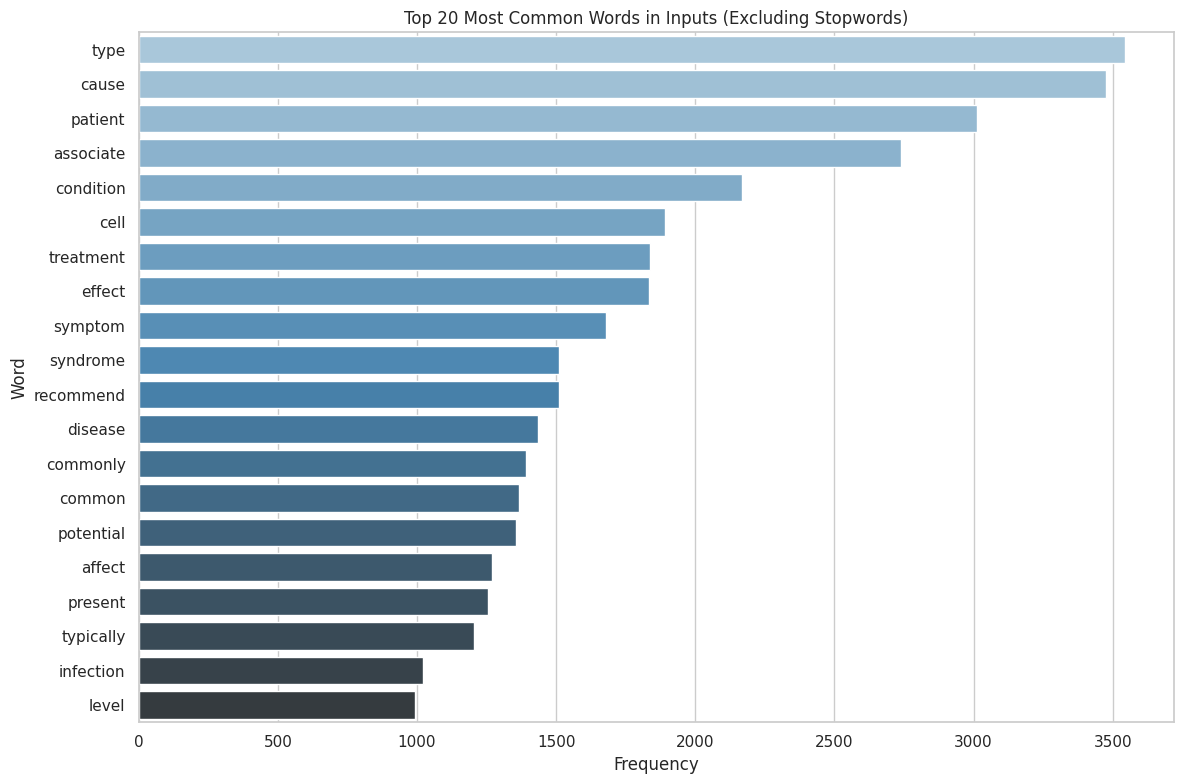

<ipython-input-65-98159cde970b>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=output_top_df2, x='Frequency', y='Word', palette='Reds_d')


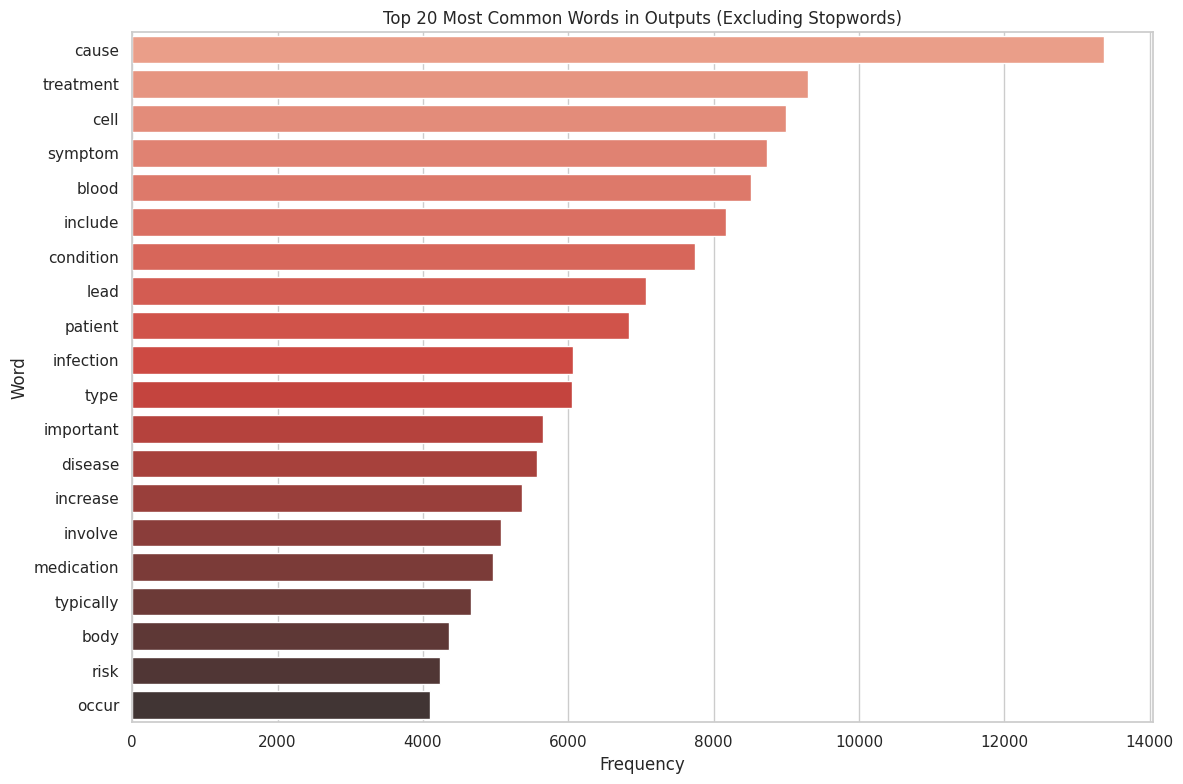

In [65]:
from collections import Counter

# Combine all tokens from inputs and outputs
all_input_tokens = [word for tokens in df2['question_tokens_spacy2'] for word in tokens]
all_output_tokens = [word for tokens in df2['answer_tokens_spacy2'] for word in tokens]

# Count frequency
input_freq = Counter(all_input_tokens)
output_freq = Counter(all_output_tokens)

# Get top 20
top_input = input_freq.most_common(20)
top_output = output_freq.most_common(20)

print("\nTop 20 Most Common Words in Inputs (Excluding Stopwords):")
print(top_input)

print("\nTop 20 Most Common Words in Outputs (Excluding Stopwords):")
print(top_output)

# Visualization of Top Words

# Inputs
input_top_df2 = pd.DataFrame(top_input, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(data=input_top_df2, x='Frequency', y='Word', palette='Blues_d')
plt.title('Top 20 Most Common Words in Inputs (Excluding Stopwords)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

# Outputs
output_top_df2 = pd.DataFrame(top_output, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(data=output_top_df2, x='Frequency', y='Word', palette='Reds_d')
plt.title('Top 20 Most Common Words in Outputs (Excluding Stopwords)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()


### Vector embeddings using openAI

In [135]:
pip install python-dotenv


In [136]:
pip install openai

Overwriting /content/.env


In [140]:
from dotenv import load_dotenv
import os

load_dotenv()  # Ensure the .env file is in the correct directory
openai_api_key = os.getenv("OPENAI_API_KEY")

if not openai_api_key:
    raise ValueError("OpenAI API key not found. Please set it in the .env file.")


In [163]:
from dotenv import load_dotenv
import os

load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")

if not openai_api_key:
    raise ValueError("OpenAI API key not found. Please set it in the .env file.")




In [141]:
from openai import OpenAI


client = OpenAI(api_key='')

In [142]:
df4 = pd.DataFrame(columns=['combined','ada_embedding'])

#We are using tokes from spacy
df4['combined'] = df2.apply(
    lambda row: ' '.join(row['question_tokens_spacy2']) + ' ' + ' '.join(row['answer_tokens_spacy2']),
    axis=1
)

# Verify the DataFrame
print(df4)
print(type(df4))

                                                combined ada_embedding
0      relationship low level pth level level low lev...           NaN
1      lead genitourinary syndrome menopause atrophic...           NaN
2      low rem sleep latency experience paralysis sug...           NaN
3      possible cause low pth high calcium level hype...           NaN
4      level hormone relate ovarian reserve level hor...           NaN
...                                                  ...           ...
33516  ataxia syndrome type cancer associate adult at...           NaN
33517  ataxia syndrome type cancer associate child at...           NaN
33518                      b proportion yes b proportion           NaN
33519  mnemonic microtubule construct poorly drug ass...           NaN
33520  age bed wet enuresis concern age old bed wetti...           NaN

[33521 rows x 2 columns]
<class 'pandas.core.frame.DataFrame'>


In [143]:
import pandas as pd
import time
from tqdm import tqdm  # For progress bar
import numpy as np
from ast import literal_eval


# This function fetches the embedding for a given text using the specified model.
def get_embedding(text, model="text-embedding-3-small"):
    text = text.replace("\n", " ")
    return client.embeddings.create(input=[text], model=model).data[0].embedding

#  Attempts to fetch the embedding with retries in case of rate limit errors.
def get_embedding_with_retry(text, model="text-embedding-3-small", max_retries=5, backoff_factor=2):
    for attempt in range(1, max_retries + 1):
        try:
            return get_embedding(text, model)
        except Exception as e:
            print(f"Attempt {attempt} failed with error: {e}")
            if attempt == max_retries:
                print("Max retries reached. Skipping this text.")
                return None
            sleep_time = backoff_factor ** attempt
            print(f"Retrying in {sleep_time} seconds...")
            time.sleep(sleep_time)


# df4 = pd.read_csv('/path/to/your/input.csv')

embeddings = []

# Define the delay between requests (in seconds)
# To stay under 50 RPS, delay should be at least 0.02 seconds
# Adding a slight buffer for safety
DELAY_BETWEEN_REQUESTS = 0.025  # 25 ms

# Iterate over the 'combined' column with a progress bar
for text in tqdm(df4['combined'], desc="Generating Embeddings"):
    embedding = get_embedding_with_retry(text, model='text-embedding-3-small')
    embeddings.append(embedding)
    time.sleep(DELAY_BETWEEN_REQUESTS)  # Respect rate limit


df4['ada_embedding'] = embeddings

df4.to_csv('/content/embedded_flashcards.csv', index=False)
print("Embeddings generated and saved successfully.")

Generating Embeddings: 100%|██████████| 33521/33521 [2:19:02<00:00,  4.02it/s]


Embeddings generated and saved successfully.


We could have used more powerful models, but the text is only in English. It doesn't require such complexity. The model that we've used is 'text-embedding-3-small.'

The file with the embeddings from OpenAI is available at this link: https://drive.google.com/drive/folders/19RtsJwWldkp85m0OGLqaFXq1nWQT_y0a?usp=drive_link


In [ ]:
# Load the embeddings
import pandas as pd

df4= pd.read_csv('/content/embedded_flashcards (1).csv')
df4['ada_embedding'] = df4.ada_embedding.apply(eval).apply(np.array)




In [ ]:
print(df4)

In [144]:
import pandas as pd
from sklearn.manifold import TSNE
import numpy as np
from ast import literal_eval

# Convert the 'ada_embedding' to an array
matrix = np.array(df4['ada_embedding'].tolist())


# Create a t-SNE model and transform the data
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='random', learning_rate=200)
vis_dims = tsne.fit_transform(matrix)
vis_dims.shape
print(tsne)

TSNE(init='random', learning_rate=200, perplexity=40, random_state=42)


In [ ]:
df4.head()

- K Means since we want to cluster in the original high-dimensional space (matrix) and prioritize accuracy.

- Perform clustering in the original high-dimensional space (matrix) to get more reliable clusters.
Use the 2D t-SNE visualization (vis_dims) for exploratory analysis.

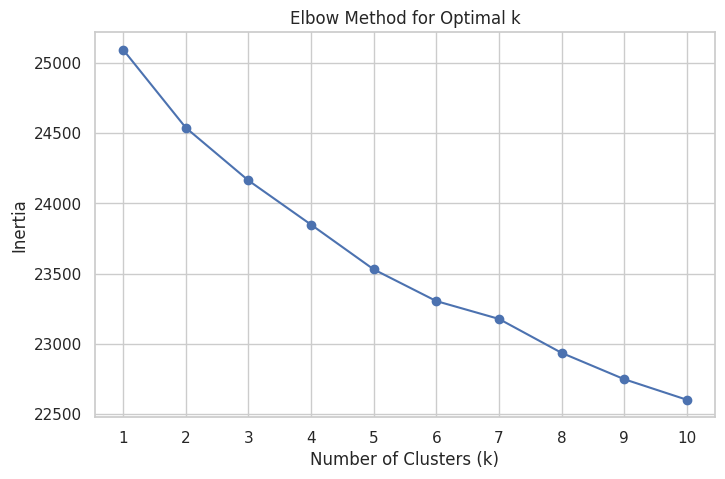

In [145]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Determine inertia for different values of k
inertia = []
k_values = range(1, 11)  # Test k from 1 to 10
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(matrix)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.show()


**We choose k=5**

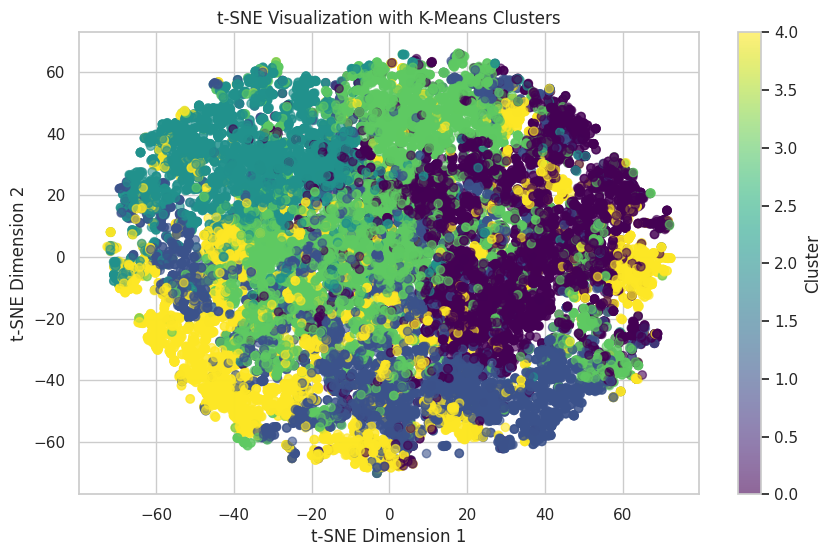

In [146]:
from sklearn.cluster import KMeans

# Perform k-means clustering
kmeans = KMeans(n_clusters=5, random_state=42)
df4['cluster'] = kmeans.fit_predict(matrix)

# Add t-SNE results to the DataFrame
df4['tsne_x'] = vis_dims[:, 0]
df4['tsne_y'] = vis_dims[:, 1]



# Visualize clusters
plt.figure(figsize=(10, 6))
plt.scatter(df4['tsne_x'], df4['tsne_y'], c=df4['cluster'], cmap='viridis', alpha=0.6)
plt.title("t-SNE Visualization with K-Means Clusters")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.colorbar(label="Cluster")
plt.show()


In [147]:
# Group the data by cluster and inspect its content
for cluster in df4['cluster'].unique():
    print(f"Cluster {cluster}:")
    print(df4[df4['cluster'] == cluster]['combined'].head(10))  # View top 10 items in the cluster
    print("\n")


Cluster 4:
0     relationship low level pth level level low lev...
37    type delusion represent statement neighbor spy...
38    substance regulate acid synthase negative feed...
39    regulator control acid synthase negative feedb...
40    enzyme convert acid porphobilinogen heme synth...
41    product conversion acid heme synthesis enzyme ...
51    result mutation gene mutation affect productio...
52    impact mutation production chain gene mutation...
56    common genetic mutation associate mutation spl...
57    common mutation associate mutation splice site...
Name: combined, dtype: object


Cluster 3:
1     lead genitourinary syndrome menopause atrophic...
3     possible cause low pth high calcium level hype...
4     level hormone relate ovarian reserve level hor...
10    relationship low dietary calcium risk calcium ...
11    condition suggest low cortisol low high infant...
12    condition associate low low pth low low pth se...
13    relationship low albumin serum total calcium

In [148]:
# Add cluster results to df4
df4['cluster'] = kmeans.labels_

# Group items by clusters and save to clustered_results
clustered_results = df4.groupby('cluster')['combined'].apply(list).reset_index()


clustered_results.columns = ['Cluster', 'Items']
print(clustered_results)


   Cluster                                              Items
0        0  [low rem sleep latency experience paralysis su...
1        1  [possible cause low glucose high level low glu...
2        2  [penicillin cephalosporin work inhibit bacteri...
3        3  [lead genitourinary syndrome menopause atrophi...
4        4  [relationship low level pth level level low le...


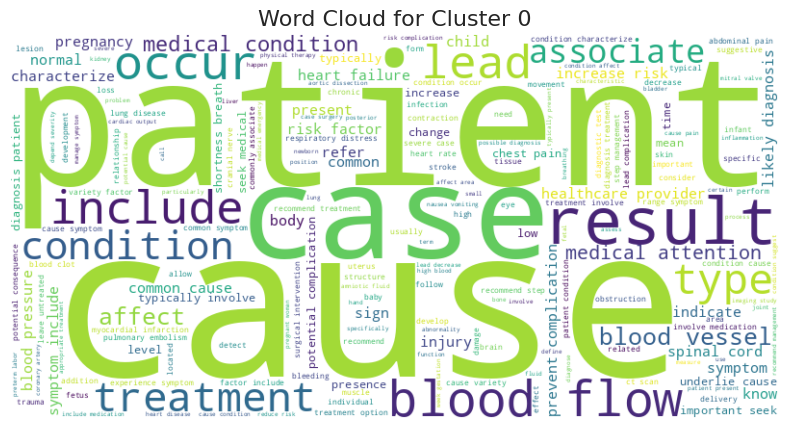

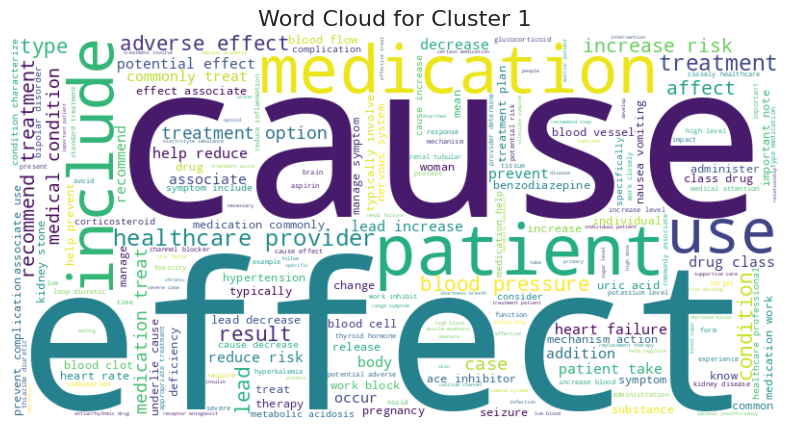

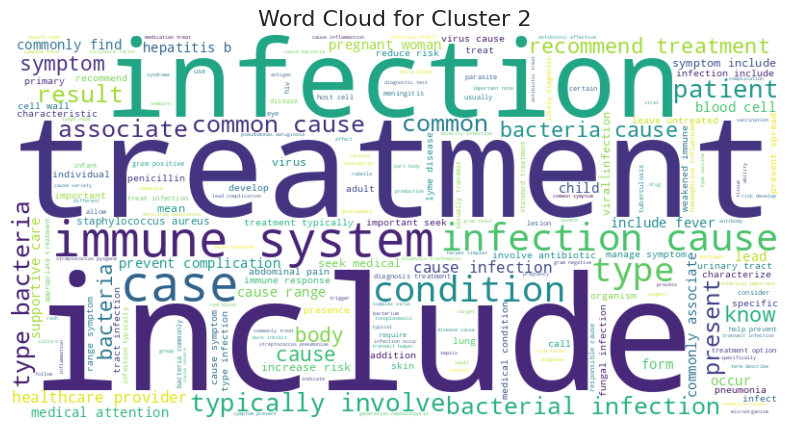

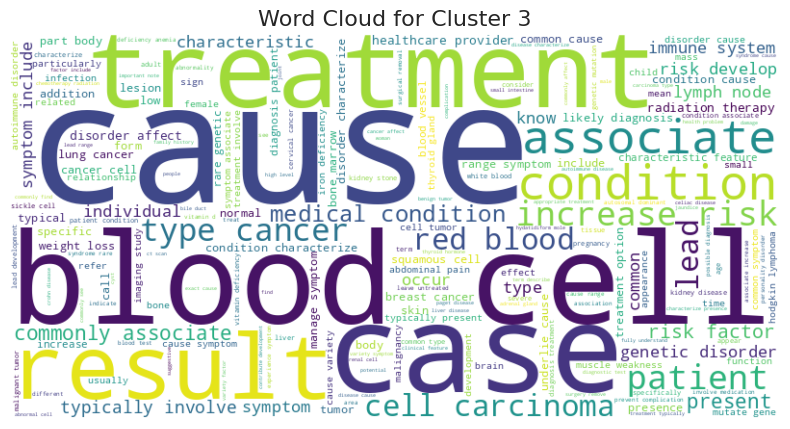

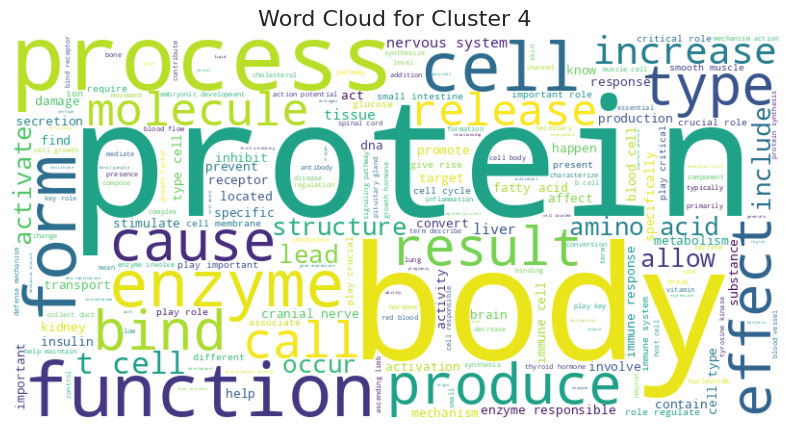

In [149]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Word clouds for each cluster
for _, row in clustered_results.iterrows():
    cluster = row['Cluster']
    items = " ".join(row['Items'])

    # Generate a word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(items)

    # Display the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for Cluster {cluster}", fontsize=16)
    plt.show()


**Analyze top cluster results**

In [150]:
# Save top 10 items per cluster in a new DataFrame
top_items_per_cluster = (
    df4.groupby('cluster')['combined']
    .apply(lambda x: x.head(10).tolist())
    .reset_index()
)


top_items_per_cluster.columns = ['Cluster', 'Top_Items']

print(top_items_per_cluster)


clustered_results.to_csv('full_clustered_results.csv', index=False) # Full result
top_items_per_cluster.to_csv('top_items_per_cluster.csv', index=False) #Only 10 results for cluster


   Cluster                                          Top_Items
0        0  [low rem sleep latency experience paralysis su...
1        1  [possible cause low glucose high level low glu...
2        2  [penicillin cephalosporin work inhibit bacteri...
3        3  [lead genitourinary syndrome menopause atrophi...
4        4  [relationship low level pth level level low le...


In [151]:
print(top_items_per_cluster['Top_Items'].head())
print(top_items_per_cluster['Top_Items'].apply(type).value_counts())


0    [low rem sleep latency experience paralysis su...
1    [possible cause low glucose high level low glu...
2    [penicillin cephalosporin work inhibit bacteri...
3    [lead genitourinary syndrome menopause atrophi...
4    [relationship low level pth level level low le...
Name: Top_Items, dtype: object
Top_Items
<class 'list'>    5
Name: count, dtype: int64


In [152]:
cluster_text = top_items_per_cluster['Top_Items'].apply(lambda x: " ".join(x))


from sklearn.feature_extraction.text import TfidfVectorizer

# Apply TF-IDF to extract keywords
vectorizer = TfidfVectorizer(stop_words='english', max_features=10)  # Limit to 10 top keywords
tfidf_matrix = vectorizer.fit_transform(cluster_text)

# Extract the keywords for each cluster
keywords = []
for row in tfidf_matrix.toarray():
    top_indices = row.argsort()[-10:][::-1]  # Get indices of the top 10 keywords
    keywords.append(" ".join(vectorizer.get_feature_names_out()[top_indices]))

# Add the keywords to the DataFrame
top_items_per_cluster['Keywords'] = keywords

# Display the updated DataFrame
print(top_items_per_cluster[['Cluster', 'Keywords']])
top_items_per_cluster.to_csv('cluster_keywords.csv', index=False)



   Cluster                                           Keywords
0        0  high low level associate cause symptom dischar...
1        1  level high low cause associate symptom dischar...
2        2  discharge symptom chill common cause associate...
3        3  low calcium high level cause associate symptom...
4        4  level low common associate symptom high discha...


- **Cluster 0:** The link between abnormal medical measurements and specific conditions.

This cluster focuses on how unusual levels of medical markers (e.g., REM sleep latency, ejection fraction, DLCO, hormone levels, etc.) relate to specific diseases or conditions like narcolepsy, emphysema, neuroblastoma, and complications during childbirth.

- **Cluster 1:** Endocrine and metabolic imbalances and their treatments.

This cluster focuses on the causes and effects of abnormal levels of substances like glucose, sodium, potassium, estrogen, aldosterone, and thyroid hormones, as well as how these imbalances are treated.

- **Cluster 2:** Antibiotics and bacterial infections.

This cluster focuses on how antibiotics like penicillin and cephalosporins stop bacterial growth and the common infections caused by *Streptococcus pneumoniae*, such as conjunctivitis, meningitis, otitis media, and pneumonia.



- **Cluster 3:** Hormonal and calcium-related conditions.

This cluster covers hormonal imbalances, calcium and PTH-related issues, and conditions like hyperparathyroidism, hypercalcemia, and ovarian reserve problems, as well as menopause-related syndromes.


- **Cluster 4:** Metabolism and genetic mutations.

This cluster explains how metabolic pathways (e.g., heme synthesis) are regulated, the role of feedback mechanisms, and how genetic mutations affect production chains, such as splice site or promoter mutations.

**3dimensional tsne**

In [153]:
from sklearn.manifold import TSNE

# Create a t-SNE model with 3 components
tsne = TSNE(
    n_components=3,        # Change to 3 for 3D
    perplexity=40,
    random_state=42,
    init='random',
    learning_rate=200
)

# Transform the data
vis_dims = tsne.fit_transform(matrix)
print("t-SNE Shape:", vis_dims.shape)


t-SNE Shape: (33521, 3)


In [154]:
import pandas as pd

# adaembedding is the embedding col
df4[['tsne_x', 'tsne_y', 'tsne_z']] = pd.DataFrame(vis_dims, index=df4.index)


In [155]:
from sklearn.cluster import KMeans

# Perform k-means clustering on the original embeddings
kmeans = KMeans(n_clusters=5, random_state=42)
df4['cluster'] = kmeans.fit_predict(matrix)



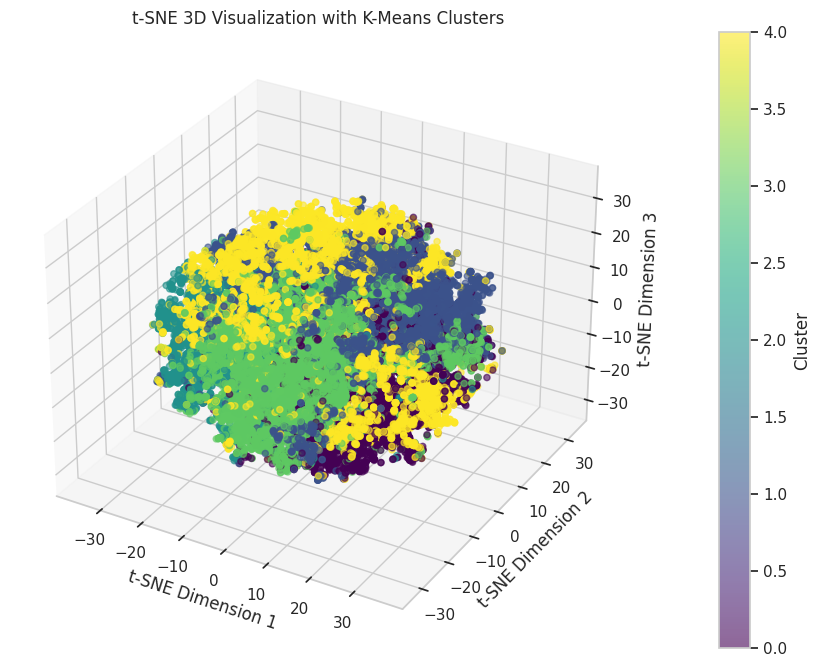

In [156]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Necessary for 3D plotting

# 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    df4['tsne_x'],
    df4['tsne_y'],
    df4['tsne_z'],
    c=df4['cluster'],
    cmap='viridis',
    alpha=0.6
)

# Add titles and labels
ax.set_title("t-SNE 3D Visualization with K-Means Clusters")
ax.set_xlabel("t-SNE Dimension 1")
ax.set_ylabel("t-SNE Dimension 2")
ax.set_zlabel("t-SNE Dimension 3")

# Add a color bar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label("Cluster")

plt.show()


In [157]:
import plotly.express as px

fig = px.scatter(
    df4,
    x='tsne_x',
    y='tsne_y',
    color='cluster',
    title="t-SNE Visualization with K-Means Clusters",
    opacity=0.6
)
fig.show()


In [158]:
import plotly.express as px

# Create a 3D scatter plot
fig = px.scatter_3d(
    df4,
    x='tsne_x',  # Dimension 1
    y='tsne_y',  # Dimension 2
    z='tsne_z',  # Dimension 3
    color='cluster',  # Coloring by cluster
    title="t-SNE 3D Visualization with K-Means Clusters",
    opacity=0.7  # Set point transparency
)

# Show the interactive plot
fig.show()


In [159]:
from scipy.spatial.distance import cdist
import pandas as pd

# Assuming df_clusters contains the t-SNE coordinates and cluster labels
# Compute centroids of each cluster in the 3D space
centroids = df4.groupby('cluster')[['tsne_x', 'tsne_y', 'tsne_z']].mean()

# Compute pairwise distances between centroids
distances = cdist(centroids, centroids, metric='euclidean')

# Convert distances to a DataFrame for better readability
distance_df = pd.DataFrame(
    distances,
    index=centroids.index,
    columns=centroids.index
)

# Display the distances
print(distance_df)


cluster          0          1          2          3          4
cluster                                                       
0         0.000000  20.017340  28.528338  20.439665  25.421216
1        20.017340   0.000000  29.446629  17.336301   9.394489
2        28.528338  29.446629   0.000000  22.453748  27.527556
3        20.439665  17.336301  22.453748   0.000000  13.213499
4        25.421216   9.394489  27.527556  13.213499   0.000000


The distance matrix shows the Euclidean distances between the centroids of the clusters. Smaller values indicate that clusters are closer in the t-SNE space, suggesting potential thematic or feature similarity, while larger values indicate greater separation and thematic distinctiveness.

Smaller distances:
- Clusters 1 and 4 have the smallest distance (9.394), suggesting these clusters are closely related or overlap in the t-SNE space.

- Clusters 1 and 3 are also relatively close (17.336), indicating moderate similarity.


Larger distances:
- Clusters 0 and 2 are the most distant (28.528), suggesting they are highly distinct in the t-SNE representation.

- Clusters 2 and 4 also have a significant separation (27.528).



In [161]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Extract items from clusters as text data
cluster_items = df4.groupby('cluster')['combined'].apply(' '.join)

# Use CountVectorizer to find common terms across clusters
vectorizer = CountVectorizer(stop_words='english', max_features=20)
X = vectorizer.fit_transform(cluster_items)

# Create a DataFrame of terms and their frequencies per cluster
terms = vectorizer.get_feature_names_out()
term_frequencies = pd.DataFrame(X.toarray(), index=cluster_items.index, columns=terms)

# Find clusters with overlapping terms
overlap_matrix = term_frequencies.T.corr()

# Display the thematic overlap matrix
print(overlap_matrix)


cluster         0         1         2         3         4
cluster                                                  
0        1.000000  0.523503  0.240935  0.437671 -0.305529
1        0.523503  1.000000 -0.004838  0.056089 -0.301879
2        0.240935 -0.004838  1.000000  0.159595 -0.100828
3        0.437671  0.056089  0.159595  1.000000  0.385596
4       -0.305529 -0.301879 -0.100828  0.385596  1.000000


Cluster 0 and Cluster 1 have a moderate correlation (0.523), indicating they share some overlapping terms, likely suggesting related themes.

Cluster 0 and Cluster 4 have a negative correlation (-0.305), showing that they are thematically distinct with little overlap in terms.

Cluster 3 and Cluster 4 have a moderate positive correlation (0.385), indicating some shared terms, possibly pointing to related subtopics.


In [166]:
# Extract terms and their frequencies for Clusters 1 and 3
cluster_0_terms = term_frequencies.loc[0]
cluster_1_terms = term_frequencies.loc[1]

# Combine terms into a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Cluster 0 Frequency': cluster_0_terms,
    'Cluster 1 Frequency': cluster_1_terms
}).sort_values(by=['Cluster 0 Frequency', 'Cluster 1 Frequency'], ascending=False)

# Add a column to highlight shared terms (where both clusters have non-zero frequency)
comparison_df['Shared Term'] = (comparison_df['Cluster 0 Frequency'] > 0) & (comparison_df['Cluster 1 Frequency'] > 0)

# Display the DataFrame
print(comparison_df)


            Cluster 0 Frequency  Cluster 1 Frequency  Shared Term
cause                      4519                 3075         True
condition                  3261                 2038         True
blood                      3076                 2361         True
patient                    2906                 3282         True
symptom                    2811                 2058         True
treatment                  2300                 3858         True
include                    2155                 1554         True
lead                       2065                 1729         True
typically                  1712                  831         True
involve                    1536                  769         True
increase                   1428                 2035         True
type                       1397                 1424         True
important                  1308                 1295         True
associate                  1242                 1185         True
risk      

### Indexing and Searching


**WHOOSH (Indexing and Searching)**

Whoosh is a pure Python search engine library that allows you to index and search text data efficiently. It uses the TF-IDF (Term Frequency-Inverse Document Frequency) algorithm by default to rank search results based on their relevance.

Whoosh handles tokenization internally based on the schema you define. Whoosh will tokenize, analyze, and process the text according to the field definitions in the schema.



In [132]:
!pip install pandas whoosh



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.8/468.8 kB 6.0 MB/s eta 0:00:00


In [133]:
flashcards_df=df2
# Check if 'id' column exists; if not, create one
if 'id' not in flashcards_df.columns:
    flashcards_df.insert(0, 'id', range(1, len(flashcards_df) + 1))

# Verify the IDs
print(flashcards_df.head())


   id                                              input  \
0   1  What is the relationship between very low Mg2+...   
1   2  What leads to genitourinary syndrome of menopa...   
2   3  What does low REM sleep latency and experienci...   
3   4  What are some possible causes of low PTH and h...   
4   5  How does the level of anti-müllerian hormone r...   

                                              output  input_length  \
0  Very low Mg2+ levels correspond to low PTH lev...            83   
1  Low estradiol production leads to genitourinar...            71   
2  Low REM sleep latency and experiencing halluci...            88   
3  PTH-independent hypercalcemia, which can be ca...            65   
4  The level of anti-müllerian hormone is directl...            71   

   output_length  input_word_count  output_word_count  input_unique_words  \
0             91                17                 18                  14   
1             91                12                 14           

In [134]:
import pandas as pd
from whoosh import index
from whoosh.fields import Schema, TEXT, ID
from whoosh.analysis import StemmingAnalyzer
from whoosh.qparser import MultifieldParser
import os
import shutil

# Generate unique IDs (if not already present)
if 'id' not in flashcards_df.columns:
    # Method 1: Incremental Integer IDs
    flashcards_df.insert(0, 'id', range(1, len(flashcards_df) + 1))



# Check validate data
required_columns = {'id', 'input', 'output'}
if not required_columns.issubset(flashcards_df.columns):
    missing = required_columns - set(flashcards_df.columns)
    raise ValueError(f"The following required columns are missing from the dataset: {missing}")

# Drop rows with missing values in required columns
flashcards_df = flashcards_df.dropna(subset=['id', 'input', 'output'])

# 4. Convert DataFrame to list of dictionaries
flashcards = flashcards_df.to_dict('records')

# 5. Define the Whoosh schema
schema = Schema(
    id=ID(stored=True, unique=True),
    input=TEXT(stored=True, analyzer=StemmingAnalyzer()),
    output=TEXT(stored=True, analyzer=StemmingAnalyzer())
)

# Create the index
index_dir = "flashcard_index"

# If the index directory exists, delete it to prevent schema mismatches
if os.path.exists(index_dir):
    shutil.rmtree(index_dir)
    print(f"Deleted existing index directory '{index_dir}' due to schema mismatch.")

# Create a new index directory
os.mkdir(index_dir)
ix = index.create_in(index_dir, schema)
print(f"Created new index with the updated schema in '{index_dir}'.")

# Index the flashcards
with ix.writer() as writer:
    for card in flashcards:
        try:
            writer.update_document(
                id=str(card["id"]),       # Ensure 'id' is a string
                input=card["input"],
                output=card["output"]
            )
        except KeyError as e:
            print(f"Missing key {e} in flashcard: {card}")
    # No need to call writer.commit() explicitly as 'with' handles it
    print("Indexing completed.")

# Define the search function
def search_flashcards(query_str, limit=10):
    with ix.searcher() as searcher:
        parser = MultifieldParser(["input", "output"], schema=ix.schema)
        try:
            query = parser.parse(query_str)
        except Exception as e:
            print(f"Error parsing query: {e}")
            return
        results = searcher.search(query, limit=limit)
        if not results:
            print("No matching flashcards found.")
            return
        for hit in results:
            print(f"ID: {hit['id']}")
            print(f"Question: {hit['input']}")
            print(f"Answer: {hit['output']}")
            print("-" * 40)

# Interactive search
if __name__ == "__main__":
    print("Flashcard Search")
    print("Type 'exit' to quit.")
    while True:
        user_query = input("Enter search query: ")
        if user_query.lower() == 'exit':
            print("Exiting search.")
            break
        search_flashcards(user_query)


Created new index with the updated schema in 'flashcard_index'.
Indexing completed.
Flashcard Search
Type 'exit' to quit.
Enter search query: disease
ID: 13696
Question: Huntington disease is a part of which class of diseases?
Answer: Huntington disease is a part of trinucleotide repeat expansion diseases.
----------------------------------------
ID: 5950
Question: What lysosomal storage disease may lead to progressive renal failure and cardiovascular disease, particularly in later stages of the disease?
Answer: Fabry disease is the lysosomal storage disease that may lead to progressive renal failure and cardiovascular disease, particularly in later stages of the disease. Fabry disease is a rare genetic disorder caused by a deficiency of the enzyme alpha-galactosidase A, which leads to the buildup of a type of fat called globotriaosylceramide in the body's cells and tissues. Symptoms of Fabry disease can vary widely, but may include skin rashes, pain in the hands and feet, and gastroin